# Practical Exercise 2 - Task 1
# Vanilla GAN on MNIST using PyTorch

In this notebook, we implement a simple Vanilla GAN to generate MNIST-like digit images.

We will:
1. Load the MNIST dataset
2. Build the Generator and Discriminator
3. Train the GAN
4. Visualize generated samples

In [1]:
# Standard library imports
import os
import math

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb

## Weights & Biases setup

In [2]:
# Configuration dictionary
config = {
    "batch_size": 64,
    "latent_dim": 100,
    "hidden_dim": 128,
    "image_dim": 28 * 28,
    "lr": 1e-3,
    "epochs": 100,
    "log_interval": 200,
    "sample_interval": 1,
    "jupyter_plot_interval": 5
}

# Shared W&B project settings
WANDB_ENTITY = "d7047e-group12"
WANDB_PROJECT = "Lab2"

# Initialize W&B
wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    config=config,
    name="task1_vanilla_gan"
)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\hamsab\_netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using device: cpu


## Load MNIST dataset

In [3]:
# Transform pipeline for MNIST
# ToTensor converts images to tensors in the range [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# DataLoader handles batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 937


## Visualize a few real images

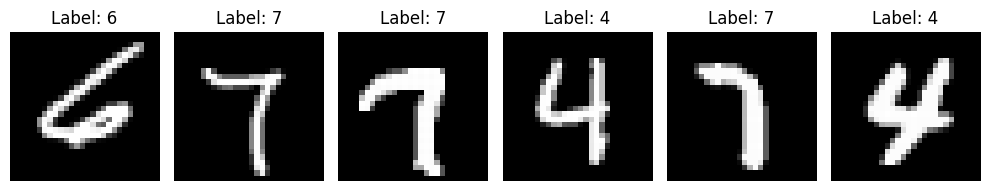

In [4]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Define the Generator network

In [5]:
# Generator model
# Input: random noise vector
# Output: fake image vector of size 784

class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, image_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)

## Define the Discriminator network

In [6]:
# Discriminator model
# Input: image vector of size 784
# Output: probability that the image is real

class Discriminator(nn.Module):
    def __init__(self, image_dim, hidden_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## Initialize models

In [7]:
# Create model instances and move them to the selected device
G = Generator(
    latent_dim=config["latent_dim"],
    hidden_dim=config["hidden_dim"],
    image_dim=config["image_dim"]
).to(device)

D = Discriminator(
    image_dim=config["image_dim"],
    hidden_dim=config["hidden_dim"]
).to(device)

print(G)
print()
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


## Define the loss function and optimizers

In [8]:
# Binary cross entropy loss is commonly used for Vanilla GAN
criterion = nn.BCELoss()

# Optimizers for Generator and Discriminator
g_optimizer = optim.Adam(G.parameters(), lr=config["lr"])
d_optimizer = optim.Adam(D.parameters(), lr=config["lr"])

## Helper function to visualize generated images

In [9]:
# Function to generate and display fake images
def show_generated_images(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    generator.train()

## Helper function for W&B image logging

In [10]:
# Function to create a matplotlib figure for W&B logging
def make_generated_figure(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    generator.train()
    return fig

## Train the Vanilla GAN

Epoch [1/100] | D_loss: 0.1524 | G_loss: 4.5933
Epoch [2/100] | D_loss: 0.0860 | G_loss: 4.6192
Epoch [3/100] | D_loss: 0.1084 | G_loss: 4.4599
Epoch [4/100] | D_loss: 0.2410 | G_loss: 4.3131
Epoch [5/100] | D_loss: 0.4363 | G_loss: 3.6440


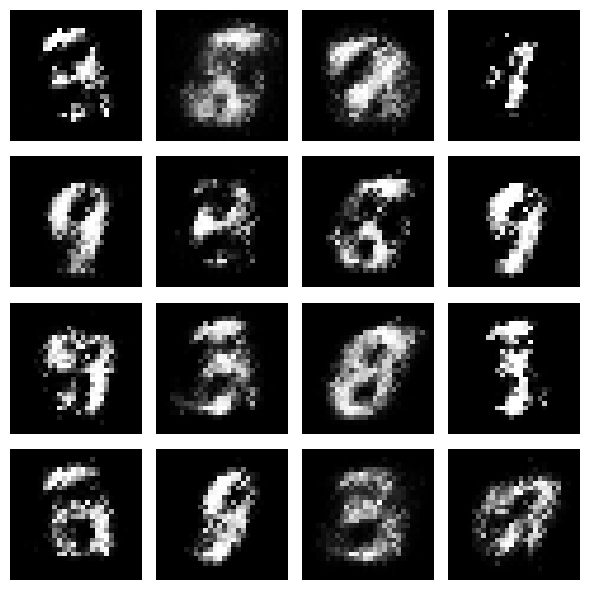

Epoch [6/100] | D_loss: 0.6730 | G_loss: 3.0713
Epoch [7/100] | D_loss: 0.7103 | G_loss: 2.7183
Epoch [8/100] | D_loss: 0.7112 | G_loss: 2.6615
Epoch [9/100] | D_loss: 0.8131 | G_loss: 2.5322
Epoch [10/100] | D_loss: 0.9191 | G_loss: 2.2772


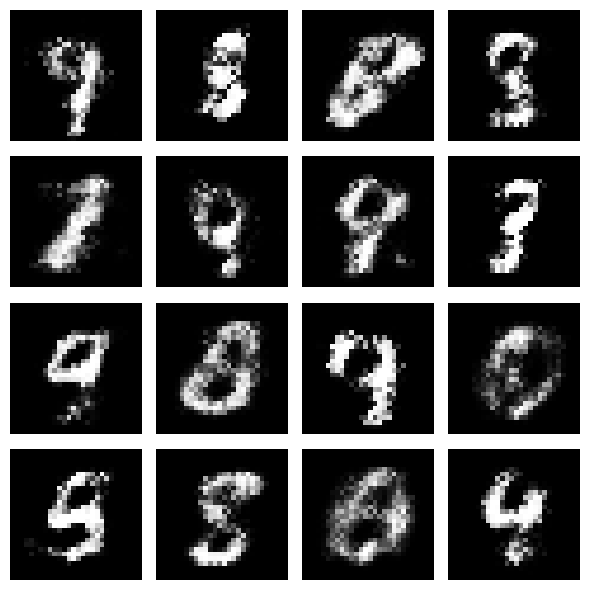

Epoch [11/100] | D_loss: 0.9584 | G_loss: 2.1739
Epoch [12/100] | D_loss: 0.9342 | G_loss: 2.0848
Epoch [13/100] | D_loss: 0.9666 | G_loss: 1.9240
Epoch [14/100] | D_loss: 0.9797 | G_loss: 1.9248
Epoch [15/100] | D_loss: 0.9475 | G_loss: 1.8897


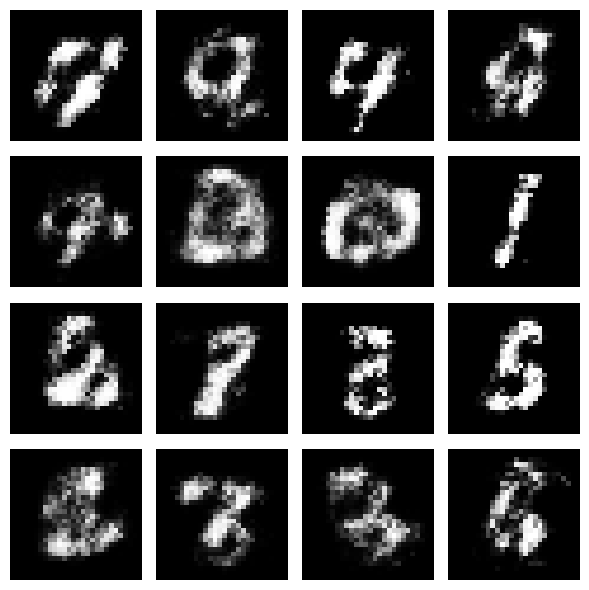

Epoch [16/100] | D_loss: 0.9784 | G_loss: 1.7877
Epoch [17/100] | D_loss: 0.9614 | G_loss: 1.7680
Epoch [18/100] | D_loss: 0.9545 | G_loss: 1.7856
Epoch [19/100] | D_loss: 0.9887 | G_loss: 1.7473
Epoch [20/100] | D_loss: 0.9436 | G_loss: 1.8305


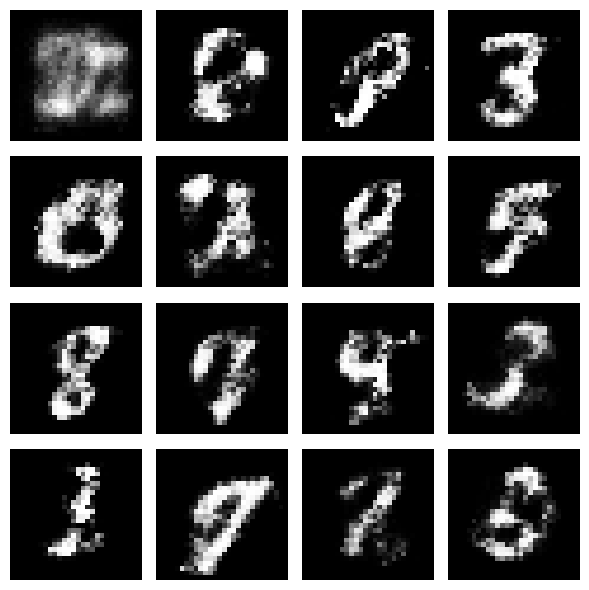

Epoch [21/100] | D_loss: 0.9848 | G_loss: 1.7224
Epoch [22/100] | D_loss: 0.9792 | G_loss: 1.7255
Epoch [23/100] | D_loss: 0.9936 | G_loss: 1.6921
Epoch [24/100] | D_loss: 1.0116 | G_loss: 1.6404
Epoch [25/100] | D_loss: 1.0145 | G_loss: 1.6115


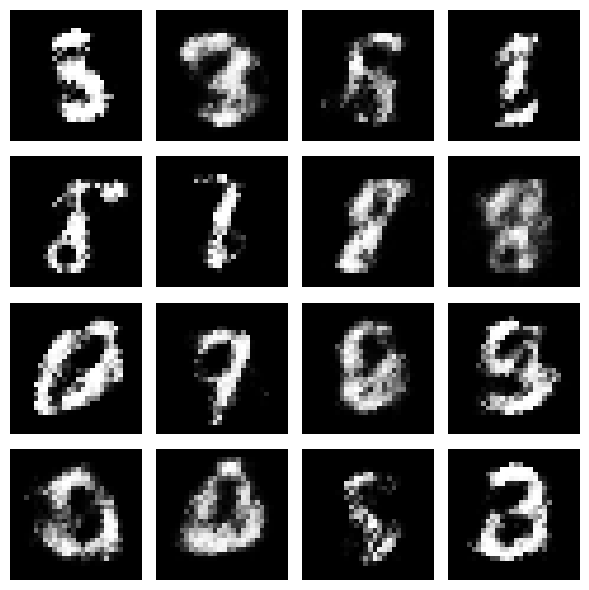

Epoch [26/100] | D_loss: 0.9931 | G_loss: 1.6323
Epoch [27/100] | D_loss: 0.9905 | G_loss: 1.6024
Epoch [28/100] | D_loss: 0.9954 | G_loss: 1.5501
Epoch [29/100] | D_loss: 0.9761 | G_loss: 1.6276
Epoch [30/100] | D_loss: 0.9712 | G_loss: 1.6772


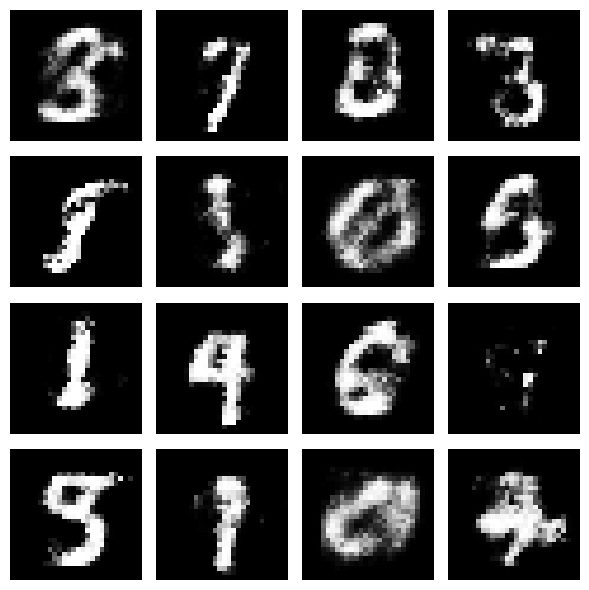

Epoch [31/100] | D_loss: 0.9843 | G_loss: 1.6778
Epoch [32/100] | D_loss: 0.9590 | G_loss: 1.6893
Epoch [33/100] | D_loss: 0.9558 | G_loss: 1.7138
Epoch [34/100] | D_loss: 0.9569 | G_loss: 1.7060
Epoch [35/100] | D_loss: 0.9590 | G_loss: 1.7235


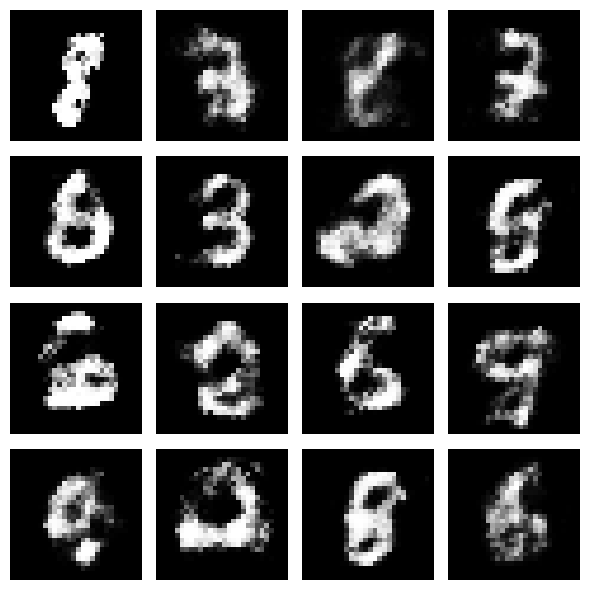

Epoch [36/100] | D_loss: 0.9663 | G_loss: 1.6618
Epoch [37/100] | D_loss: 0.9666 | G_loss: 1.6683
Epoch [38/100] | D_loss: 0.9514 | G_loss: 1.6411
Epoch [39/100] | D_loss: 0.9531 | G_loss: 1.6472
Epoch [40/100] | D_loss: 0.9657 | G_loss: 1.5986


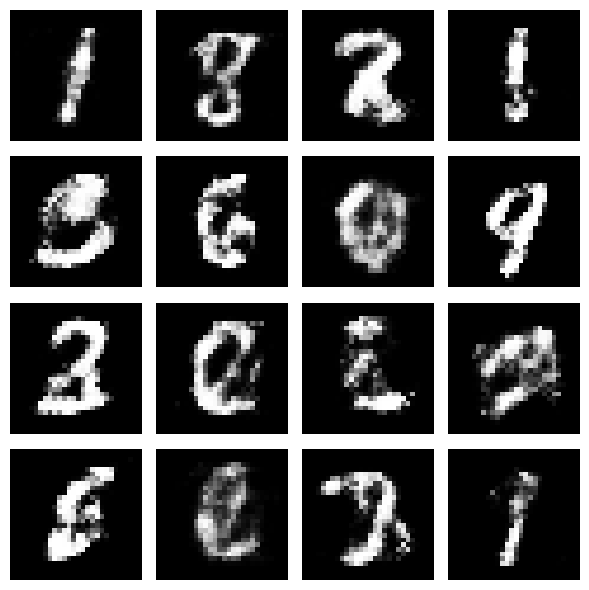

Epoch [41/100] | D_loss: 0.9539 | G_loss: 1.6133
Epoch [42/100] | D_loss: 0.9516 | G_loss: 1.6584
Epoch [43/100] | D_loss: 0.9374 | G_loss: 1.7145
Epoch [44/100] | D_loss: 0.9286 | G_loss: 1.7314
Epoch [45/100] | D_loss: 0.9352 | G_loss: 1.7003


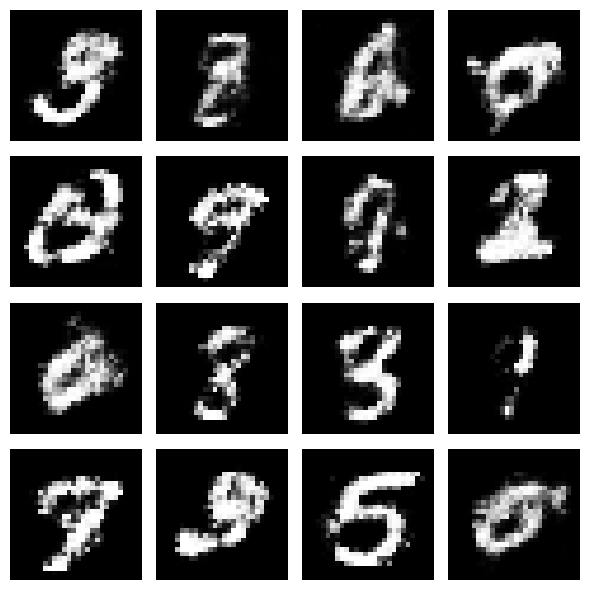

Epoch [46/100] | D_loss: 0.9279 | G_loss: 1.6712
Epoch [47/100] | D_loss: 0.9208 | G_loss: 1.6746
Epoch [48/100] | D_loss: 0.9371 | G_loss: 1.6544
Epoch [49/100] | D_loss: 0.9252 | G_loss: 1.6707
Epoch [50/100] | D_loss: 0.9131 | G_loss: 1.6893


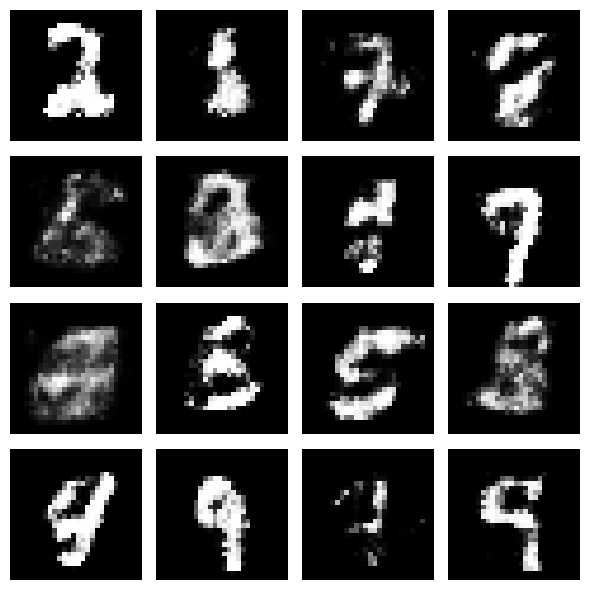

Epoch [51/100] | D_loss: 0.9133 | G_loss: 1.7075
Epoch [52/100] | D_loss: 0.9108 | G_loss: 1.6884
Epoch [53/100] | D_loss: 0.9077 | G_loss: 1.7200
Epoch [54/100] | D_loss: 0.9093 | G_loss: 1.7131
Epoch [55/100] | D_loss: 0.9030 | G_loss: 1.7128


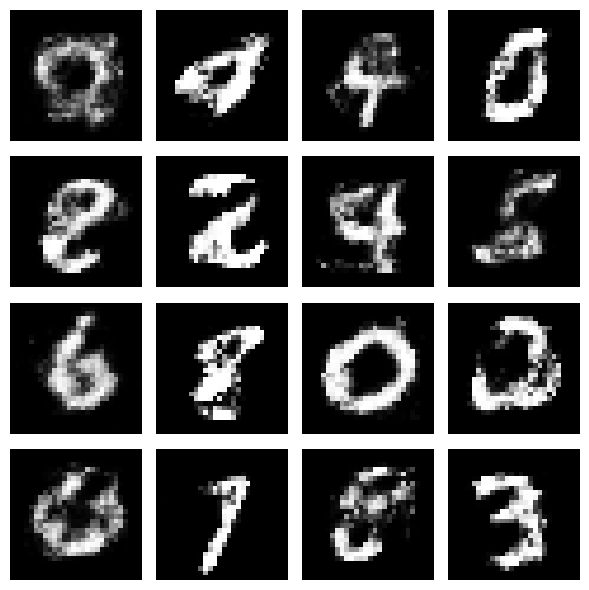

Epoch [56/100] | D_loss: 0.9021 | G_loss: 1.7352
Epoch [57/100] | D_loss: 0.8941 | G_loss: 1.7493
Epoch [58/100] | D_loss: 0.8955 | G_loss: 1.7890


In [ ]:
# Main training loop with epoch-level W&B logging

for epoch in range(config["epochs"]):
    # Lists to store batch losses for this epoch
    d_loss_list = []
    g_loss_list = []
    d_real_loss_list = []
    d_fake_loss_list = []

    for batch_idx, (real_images, _) in enumerate(train_loader):
        # Flatten real images from [batch, 1, 28, 28] to [batch, 784]
        real_images = real_images.view(-1, config["image_dim"]).to(device)
        batch_size = real_images.size(0)

        # Create labels for real and fake samples
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # =========================================================
        # 1) Train the Discriminator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        d_real = D(real_images)
        d_fake = D(fake_images.detach())

        d_real_loss = criterion(d_real, real_labels)
        d_fake_loss = criterion(d_fake, fake_labels)
        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # =========================================================
        # 2) Train the Generator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        d_fake_for_g = D(fake_images)
        g_loss = criterion(d_fake_for_g, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Store batch losses for epoch-level averaging
        d_loss_list.append(d_loss.item())
        g_loss_list.append(g_loss.item())
        d_real_loss_list.append(d_real_loss.item())
        d_fake_loss_list.append(d_fake_loss.item())

    # =============================================================
    # 3) Compute average losses for the epoch
    # =============================================================
    avg_d_loss = np.mean(d_loss_list)
    avg_g_loss = np.mean(g_loss_list)
    avg_d_real_loss = np.mean(d_real_loss_list)
    avg_d_fake_loss = np.mean(d_fake_loss_list)

    # Print one clean summary per epoch
    print(
        f"Epoch [{epoch+1}/{config['epochs']}] | "
        f"D_loss: {avg_d_loss:.4f} | "
        f"G_loss: {avg_g_loss:.4f}"
    )

    # =============================================================
    # 4) Log scalar metrics once per epoch
    # =============================================================
    wandb.log({
        "epoch": epoch + 1,
        "D_loss": avg_d_loss,
        "G_loss": avg_g_loss,
        "D_real_loss": avg_d_real_loss,
        "D_fake_loss": avg_d_fake_loss
    }, step=epoch + 1)
    
    # =============================================================
    # 5) Log generated images every epoch to W&B
    #    Show images in Jupyter only every 5 epochs
    # =============================================================
    fig = make_generated_figure(G, config["latent_dim"], num_images=16)
    
    wandb.log({
        "generated_samples": wandb.Image(fig, caption=f"Epoch {epoch+1}")
    }, step=epoch + 1)
    
    # Show images inside Jupyter Lab only every 5 epochs
    if (epoch + 1) % config["jupyter_plot_interval"] == 0:
        plt.show()
    
    plt.close(fig)

## Display final generated samples

In [ ]:
# Display final generated images after training
show_generated_images(G, config["latent_dim"], num_images=16)

## Save final generated samples locally

In [ ]:
# Create output directory if it does not exist
os.makedirs("out", exist_ok=True)

# Generate final samples
G.eval()
with torch.no_grad():
    z = torch.randn(16, config["latent_dim"], device=device)
    final_images = G(z).view(-1, 28, 28).cpu().numpy()

# Save the samples as a grid
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(final_images[i], cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.savefig("out/task1_final_samples.png", bbox_inches="tight")
plt.show()
plt.close()

print("Saved final generated samples to: out/task1_final_samples.png")

## Finish the W&B run

In [ ]:
wandb.finish()